In [1]:
from pathlib import Path
from datetime import time

import matplotlib.pyplot as plt
import pandas as pd
import requests

In [2]:
BASE_URL = "https://ckan0.cf.opendata.inter.prod-toronto.ca"
PACKAGE_ID = "pre-hospital-emergency-care-performance-metrics"

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")

RAW_DATA_PATH = DATA_DIR / "pre_hospital_emergency_care_metrics.xlsx"
CLEAN_DATA_PATH = DATA_DIR / "pre_hospital_metrics_clean.csv"
PYTHON_OUTPUT_PATH = OUTPUT_DIR / "viz1_python_requests_vs_transports.png"

DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

downloaded dataset from Toronto open data API: https://open.toronto.ca/dataset/pre-hospital-emergency-care-performance-metrics/

In [3]:
def get_package_metadata() -> dict:
    url = f"{BASE_URL}/api/3/action/package_show"
    params = {"id": PACKAGE_ID}

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()

    package = response.json()

    if not package.get("success"):
        raise RuntimeError("Toronto Open Data API did not return a successful response.")

    return package["result"]


def find_excel_resource(package: dict) -> dict:
    resources = package.get("resources", [])

    for resource in resources:
        resource_url = resource.get("url", "")
        resource_format = resource.get("format", "")

        is_excel_url = resource_url.lower().endswith((".xlsx", ".xls"))
        is_excel_format = resource_format.lower() in ["xlsx", "xls", "excel"]

        if is_excel_url or is_excel_format:
            return resource

    available_resources = [
        {
            "name": resource.get("name"),
            "format": resource.get("format"),
            "url": resource.get("url"),
        }
        for resource in resources
    ]

    raise RuntimeError(
        "Could not find an Excel resource. Available resources:\n"
        f"{available_resources}"
    )


def download_file(url: str, output_path: Path) -> None:
    response = requests.get(url, timeout=60)
    response.raise_for_status()

    output_path.write_bytes(response.content)


package = get_package_metadata()
resource = find_excel_resource(package)

print("Found resource:")
print(f"Name: {resource.get('name')}")
print(f"Format: {resource.get('format')}")
print(f"URL: {resource.get('url')}")

download_file(resource["url"], RAW_DATA_PATH)

print(f"\nSaved raw dataset to: {RAW_DATA_PATH}")

Found resource:
Name: Pre-hospital emergency care performance metrics 2014-2025
Format: XLSX
URL: https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/174ace54-bcc7-4885-85c1-76094ab4a0ca/resource/1cbf17c7-1841-4bc5-a6ca-add2b4dcdeef/download/opendata_pre-hospital-emergency-care-performance-metrics-2014-2025.xlsx

Saved raw dataset to: data/pre_hospital_emergency_care_metrics.xlsx


In [4]:
%pip install openpyxl

/Users/francesbruno/visualization/visualization-env/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


inspecting file


In [7]:
excel_file = pd.ExcelFile(RAW_DATA_PATH)

print("Sheet names:")
print(excel_file.sheet_names)

Sheet names:
['Pre-hospital Emergency Care', 'Read-Me']


main sheet preview

In [8]:
raw_df = pd.read_excel(RAW_DATA_PATH, sheet_name="Pre-hospital Emergency Care")

print(raw_df.shape)
raw_df.head()

(36, 4)


,Pre-Hospital Emergency Care Type,Year,Actual,Unit of Measure
0,Emergency Request for Service,2014,270430,Number
1,Emergency Request for Service,2015,277887,Number
2,Emergency Request for Service,2016,295548,Number
3,Emergency Request for Service,2017,304313,Number
4,Emergency Request for Service,2018,325140,Number


In [9]:
# checking column names

raw_df.columns.tolist()

['Pre-Hospital Emergency Care Type', 'Year', 'Actual', 'Unit of Measure']

In [10]:
#clean data

def time_to_minutes(value: object) -> float:
    if isinstance(value, time):
        if value.hour > 0 and value.second == 0:
            return value.hour + (value.minute / 60)

        return (value.hour * 60) + value.minute + (value.second / 60)

    if isinstance(value, str):
        parts = value.strip().split(":")

        if len(parts) == 3:
            hours = int(parts[0])
            minutes = int(parts[1])
            seconds = int(parts[2])

            if hours > 0 and seconds == 0:
                return hours + (minutes / 60)

            return (hours * 60) + minutes + (seconds / 60)

        if len(parts) == 2:
            minutes = int(parts[0])
            seconds = int(parts[1])
            return minutes + (seconds / 60)

    return float(value)


def create_value_label(row: pd.Series) -> str:
    if str(row["unit"]).lower() == "number":
        return f"{int(row['value']):,}"

    total_seconds = int(round(float(row["value"]) * 60))
    minutes = total_seconds // 60
    seconds = total_seconds % 60

    return f"{minutes}:{seconds:02d}"


def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()
    cleaned.columns = (
        cleaned.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return cleaned


def clean_pre_hospital_data(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = clean_column_names(df)

    cleaned = cleaned.rename(
        columns={
            "pre_hospital_emergency_care_type": "metric",
            "actual": "actual_raw",
            "unit_of_measure": "unit",
        }
    )

    required_columns = ["metric", "year", "actual_raw", "unit"]
    missing_columns = [
        column for column in required_columns if column not in cleaned.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing columns: {missing_columns}. "
            f"Available columns: {cleaned.columns.tolist()}"
        )

    cleaned["metric"] = cleaned["metric"].astype(str).str.strip()
    cleaned["year"] = pd.to_numeric(cleaned["year"], errors="coerce")
    cleaned["unit"] = cleaned["unit"].astype(str).str.strip()

    number_mask = cleaned["unit"].str.lower().eq("number")
    minutes_mask = cleaned["unit"].str.lower().str.contains("minutes")

    cleaned.loc[number_mask, "value"] = pd.to_numeric(
        cleaned.loc[number_mask, "actual_raw"],
        errors="coerce",
    )

    cleaned.loc[minutes_mask, "value"] = cleaned.loc[
        minutes_mask,
        "actual_raw",
    ].apply(time_to_minutes)

    cleaned["value_label"] = cleaned.apply(create_value_label, axis=1)

    cleaned = cleaned.dropna(subset=["metric", "year", "value"])
    cleaned["year"] = cleaned["year"].astype(int)

    return cleaned[["metric", "year", "value", "value_label", "unit"]]


clean_df = clean_pre_hospital_data(raw_df)

clean_df.head()

,metric,year,value,value_label,unit
0,Emergency Request for Service,2014,270430.0,"270,430",Number
1,Emergency Request for Service,2015,277887.0,"277,887",Number
2,Emergency Request for Service,2016,295548.0,"295,548",Number
3,Emergency Request for Service,2017,304313.0,"304,313",Number
4,Emergency Request for Service,2018,325140.0,"325,140",Number


In [11]:
#checking available metrics I can work with
clean_df["metric"].unique()

array(['Emergency Request for Service', 'Emergency Transport Records',
       'Arrival to Life Threatening Calls 90% of Time'], dtype=object)

In [12]:
#checking units
clean_df.groupby(["metric", "unit"]).size()

metric                                         unit           
Arrival to Life Threatening Calls 90% of Time  Minutes:Seconds    12
Emergency Request for Service                  Number             12
Emergency Transport Records                    Number             12
dtype: int64

In [13]:
clean_df.to_csv(CLEAN_DATA_PATH, index=False)

print(f"Saved cleaned CSV to: {CLEAN_DATA_PATH}")

Saved cleaned CSV to: data/pre_hospital_metrics_clean.csv


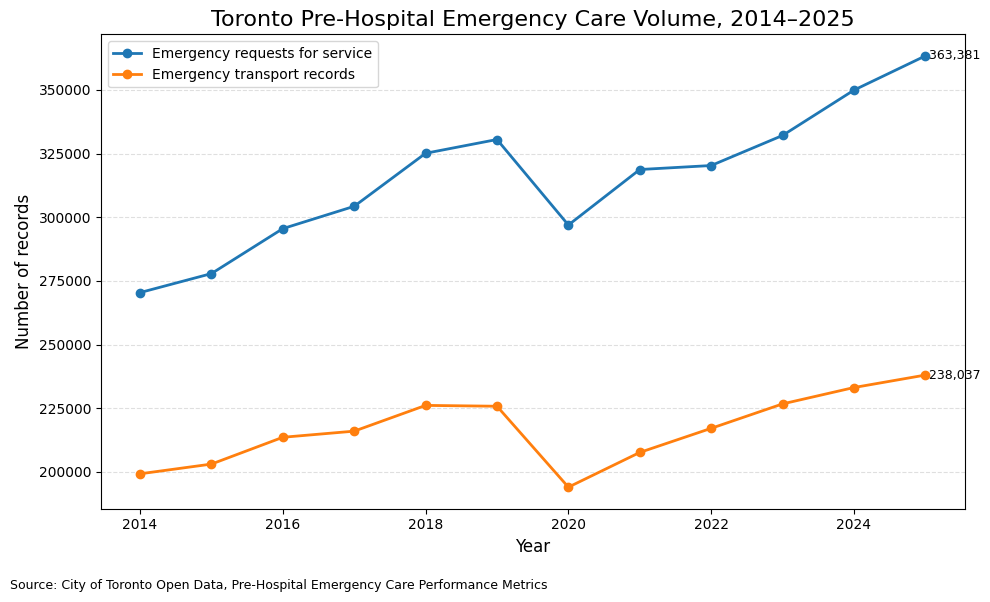

Saved Python visualization to: outputs/viz1_python_requests_vs_transports.png


In [ ]:
# VIsualization 1: Comparing emergency requests and emergency transport records over time.
# Creating figure and axes, then a few customizations with labels, title, legend, etc
REQUESTS_METRIC = "Emergency Request for Service"
TRANSPORTS_METRIC = "Emergency Transport Records"


def get_metric_data(df: pd.DataFrame, metric_name: str) -> pd.DataFrame:
    metric_df = df[df["metric"] == metric_name].copy()

    if metric_df.empty:
        available_metrics = sorted(df["metric"].unique())
        raise ValueError(
            f"Could not find metric: {metric_name}. "
            f"Available metrics are: {available_metrics}"
        )

    return metric_df.sort_values("year")


requests_df = get_metric_data(clean_df, REQUESTS_METRIC)
transports_df = get_metric_data(clean_df, TRANSPORTS_METRIC)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    requests_df["year"],
    requests_df["value"],
    marker="o",
    linewidth=2,
    label="Emergency requests for service",
)

ax.plot(
    transports_df["year"],
    transports_df["value"],
    marker="o",
    linewidth=2,
    label="Emergency transport records",
)

ax.set_title(
    "Toronto Pre-Hospital Emergency Care Volume, 2014–2025",
    fontsize=16,
)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of records", fontsize=12)

ax.legend(loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)

latest_requests = requests_df.iloc[-1]
latest_transports = transports_df.iloc[-1]

ax.text(
    latest_requests["year"],
    latest_requests["value"],
    f" {latest_requests['value_label']}",
    va="center",
    fontsize=9,
)

ax.text(
    latest_transports["year"],
    latest_transports["value"],
    f" {latest_transports['value_label']}",
    va="center",
    fontsize=9,
)

fig.text(
    0.01,
    0.01,
    "Source: City of Toronto Open Data, Pre-Hospital Emergency Care Performance Metrics",
    ha="left",
    fontsize=9,
)

fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(PYTHON_OUTPUT_PATH, dpi=300)

plt.show()

print(f"Saved Python visualization to: {PYTHON_OUTPUT_PATH}")

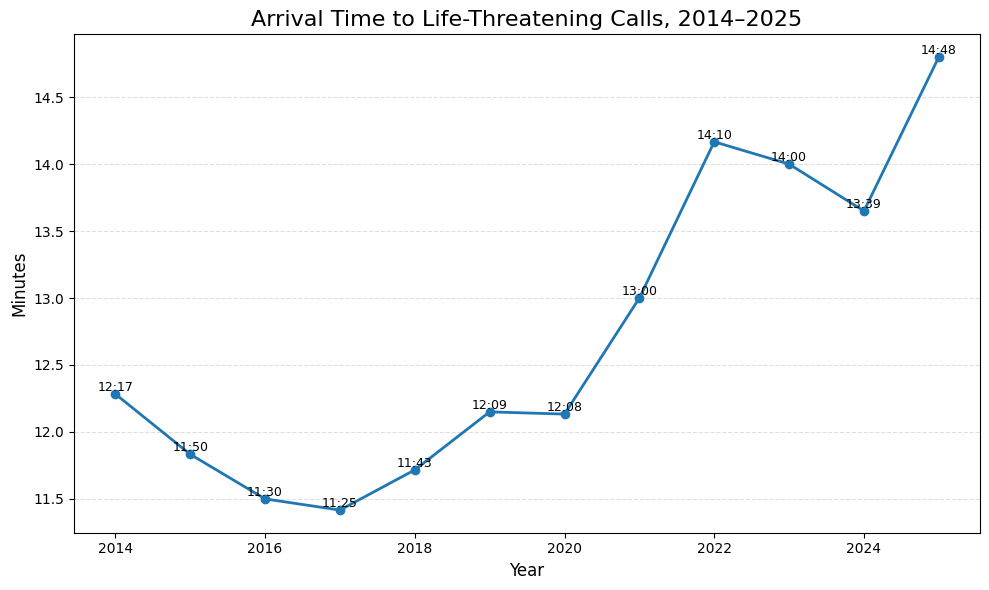

In [15]:
#arrival-time chart
ARRIVAL_METRIC = "Arrival to Life Threatening Calls 90% of Time"

arrival_df = get_metric_data(clean_df, ARRIVAL_METRIC)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    arrival_df["year"],
    arrival_df["value"],
    marker="o",
    linewidth=2,
)

ax.set_title(
    "Arrival Time to Life-Threatening Calls, 2014–2025",
    fontsize=16,
)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Minutes", fontsize=12)

ax.grid(axis="y", linestyle="--", alpha=0.4)

for _, row in arrival_df.iterrows():
    ax.text(
        row["year"],
        row["value"],
        row["value_label"],
        ha="center",
        va="bottom",
        fontsize=9,
    )

fig.tight_layout()
plt.show()